In [1]:
import xrayutilities as xu
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from pybaselines import Baseline, utils
import numpy as np
from pymatgen.core import Lattice, Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

In [49]:
# Load XRDML file
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\XRD\new_XRD")
file_list = []

In [50]:
pattern_mapping = {
    '*_1.xrdml': 'Chemical Etching',
    '*_2.xrdml': 'Chemical Etching + Anodising',
    '*_A1.xrdml': 'Industrial Etching',
    '*_A2.xrdml': 'Industrial Etching + Anodising'
}

In [3]:
pattern_mapping = {
    '*_1.xrdml':'Control',
    '*_VA.xrdml': r'NaVO$_3$ after immersion',
    '*_VB.xrdml': r'NaVO$_3$ before immersion',
    '*_MBTA.xrdml': 'MBT after immersion',
    '*_MBTB.xrdml': 'MBT before immersion'
}

In [51]:
file_list = []

for p, name in pattern_mapping.items():
    for filename in main_dir.rglob(p):
        file_list.append((filename, name))

datasets = []

for filename,name in file_list:
    data = xu.io.XRDMLFile(str(filename))
    xrd_data = {
        'filename': filename.name,
        'name': name,
        'two_theta': data.scan['2Theta'],
        'intensity_original': data.scan['detector']*data.scan['countTime'],
        'intensity_filtered' : None,
        'k_alpha_1': 1.5405980,
        'k_alpha_2': 1.5444260,
        'k_alpha': (2*1.5405980 + 1.5444260)/3,
        'two_theta_003':None,
        'intensity_003':None,
        'two_theta_006':None,
        'intensity_006':None,
        'basal_spacing': None,
        'gallery_height':None
        
    }

    datasets.append ({'xrd_data':xrd_data})


In [52]:
layer_thickness = 4.77 #value in angstrom

for data in datasets:
    baseline_fitter = Baseline(x_data=data['xrd_data']['two_theta'])
    #bkg_4, params_4 = baseline_fitter.mor(data['xrd_data']['intensity_original'])
    bkg_4, params_4 = baseline_fitter.airpls(data['xrd_data']['intensity_original'],lam=1e6)
    data['xrd_data']['intensity_filtered'] = data['xrd_data']['intensity_original'] - bkg_4
    
    mask_003 = (np.array(data['xrd_data']['two_theta']) < 15) & (np.array(data['xrd_data']['two_theta']) > 5)
    two_theta_cut_003 = data['xrd_data']['two_theta'][mask_003]
    intensity_cut_003 = data['xrd_data']['intensity_filtered'][mask_003]
    
    idx_max_003 = np.argmax(intensity_cut_003)
    two_theta_003 = two_theta_cut_003[idx_max_003]
    intensity_003 = intensity_cut_003[idx_max_003]
    theta_radians_003 = np.radians(two_theta_003 / 2)
    
    wavelength = data['xrd_data']['k_alpha']
    basal_spacing = wavelength / (2 * np.sin(theta_radians_003))
    gallery_height = basal_spacing - layer_thickness

    mask_006 = (np.array(data['xrd_data']['two_theta']) < 21.5) & (np.array(data['xrd_data']['two_theta']) > 17.5)
    two_theta_cut_006 = data['xrd_data']['two_theta'][mask_006]
    intensity_cut_006 = data['xrd_data']['intensity_filtered'][mask_006]
    
    idx_max_006 = np.argmax(intensity_cut_006)
    two_theta_006 = two_theta_cut_006[idx_max_006]
    intensity_006 = intensity_cut_006[idx_max_006]

    data['xrd_data']['basal_spacing'] = basal_spacing
    data['xrd_data']['gallery_height'] = gallery_height
    data['xrd_data']['two_theta_003'] = two_theta_003
    data['xrd_data']['intensity_003'] = intensity_003
    data['xrd_data']['two_theta_006'] = two_theta_006
    data['xrd_data']['intensity_006'] = intensity_006
    


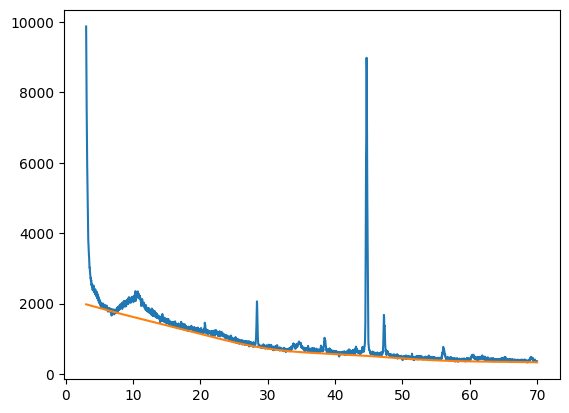

In [6]:
baseline_fitter = Baseline(x_data=datasets[1]['xrd_data']['two_theta'])
bkg_4, params_4 = baseline_fitter.airpls(datasets[1]['xrd_data']['intensity_original'],lam=1e7)
plt.plot(datasets[1]['xrd_data']['two_theta'],datasets[1]['xrd_data']['intensity_original'])
plt.plot(datasets[1]['xrd_data']['two_theta'],bkg_4)
plt.show()


4.197852620675304
3.7781249844531875
4.531617022221701


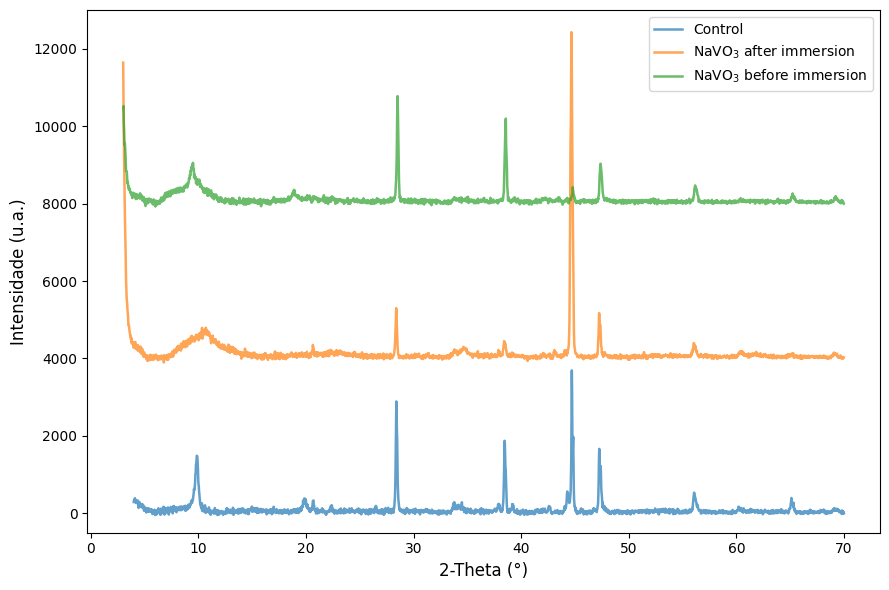

In [30]:
plt.figure(figsize=(9, 6))

offset = 4000

for i, data in enumerate(datasets):
    plt.plot(
        data['xrd_data']['two_theta'], 
        data['xrd_data']['intensity_filtered'] + (offset * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=data['xrd_data']['name']
    )    
    print(data['xrd_data']['gallery_height'])

#plt.xlim(5, 20)
plt.ylim(-500,13000)

plt.xlabel('2-Theta (°)', fontsize=12)
plt.ylabel('Intensidade (u.a.)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()    

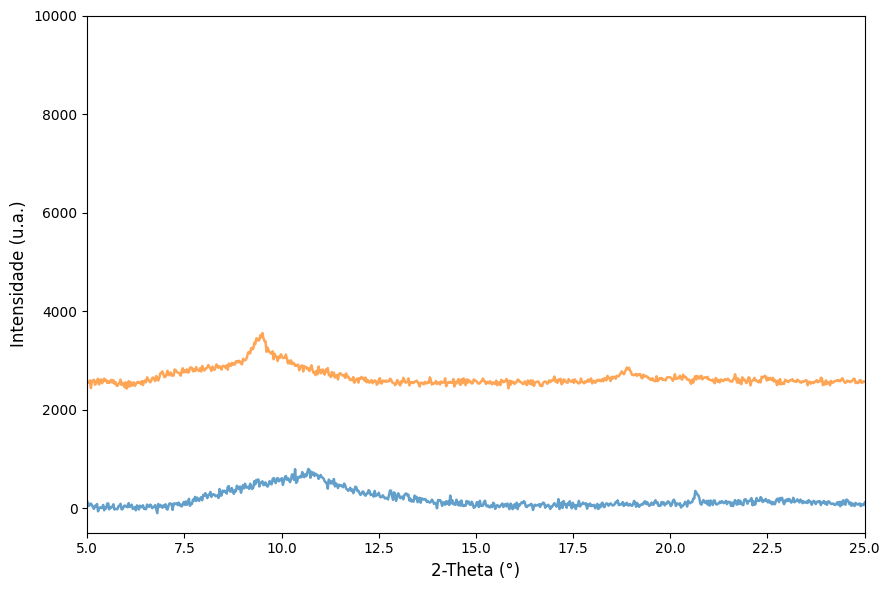

In [24]:
plt.figure(figsize=(9, 6))

offset = 2500

for i, data in enumerate(datasets):
    plt.plot(
        data['xrd_data']['two_theta'], 
        data['xrd_data']['intensity_filtered'] + (offset * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=data['xrd_data']['name']
    )    

plt.xlim(5, 25)
plt.ylim(-500,10000)

plt.xlabel('2-Theta (°)', fontsize=12)
plt.ylabel('Intensidade (u.a.)', fontsize=12)
plt.tight_layout()
plt.show()   

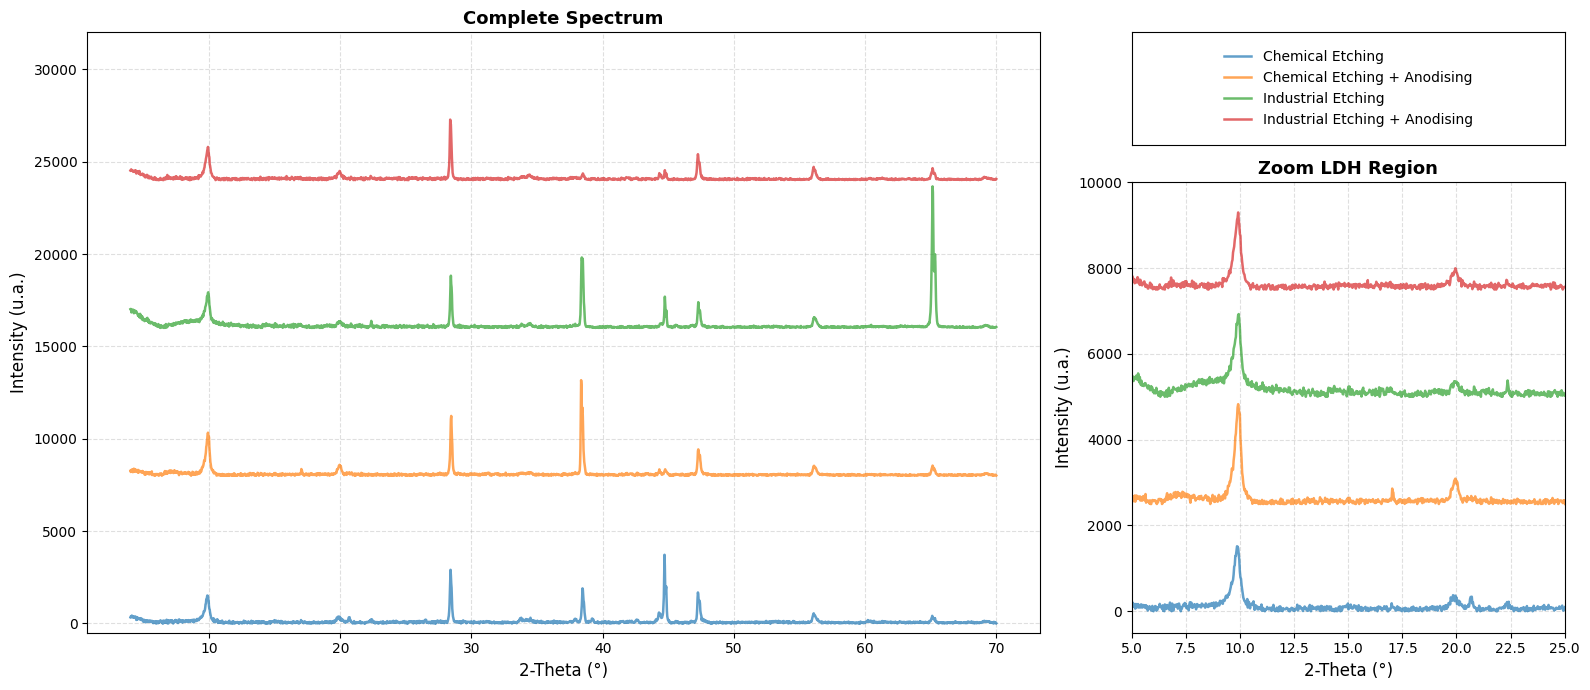

In [17]:
fig = plt.figure(figsize=(16, 7))

# 2. Definir a grelha (2 linhas e 2 colunas)
# width_ratios=[2.2, 1] faz a coluna da esquerda ser mais do dobro da largura da direita
# height_ratios=[1, 4] faz o bloco da legenda ser mais baixo que o bloco do Zoom
gs = gridspec.GridSpec(2, 2, width_ratios=[2.2, 1], height_ratios=[1, 4])

# 3. Alocar os eixos com base no teu esquema
ax_overall = fig.add_subplot(gs[:, 0])  # Ocupa as duas linhas da primeira coluna
ax_leg     = fig.add_subplot(gs[0, 1])  # Linha 0, Coluna 1 (Topo Direito)
ax_zoom    = fig.add_subplot(gs[1, 1])  # Linha 1, Coluna 1 (Baixo Direito)

# Definição dos teus offsets anteriores
offset_completo = 8000
offset_zoom = 2500

# Loop para plotar os dados nos respetivos eixos
for i, data in enumerate(datasets):
    x = data['xrd_data']['two_theta']
    y = data['xrd_data']['intensity_filtered']
    name = data['xrd_data']['name']
    
    # Plot no painel "OVERALL"
    ax_overall.plot(
        x, 
        y + (offset_completo * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=name
    )
    
    # Plot no painel "ZOOM IN"
    ax_zoom.plot(
        x, 
        y + (offset_zoom * i), 
        alpha=0.7, 
        linewidth=1.8
    )


ax_overall.set_ylim(-500, 32000)
ax_overall.set_xlabel('2-Theta (°)', fontsize=12)
ax_overall.set_ylabel('Intensity (u.a.)', fontsize=12)
ax_overall.set_title('Complete Spectrum', fontsize=13, fontweight='bold')
ax_overall.grid(True, linestyle='--', alpha=0.4)


ax_leg.get_xaxis().set_visible(False)
ax_leg.get_yaxis().set_visible(False)

handles, labels = ax_overall.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', frameon=False, fontsize=10)


ax_zoom.set_xlim(5, 25)
ax_zoom.set_ylim(-500, 10000)
ax_zoom.set_xlabel('2-Theta (°)', fontsize=12)
ax_zoom.set_ylabel('Intensity (u.a.)', fontsize=12)
ax_zoom.set_title('Zoom LDH Region', fontsize=13, fontweight='bold')
ax_zoom.grid(True, linestyle='--', alpha=0.4)

# Ajustar margens automaticamente para evitar sobreposições
plt.tight_layout()
#plt.savefig('XRD_LDH.pdf', bbox_inches='tight')
plt.show()

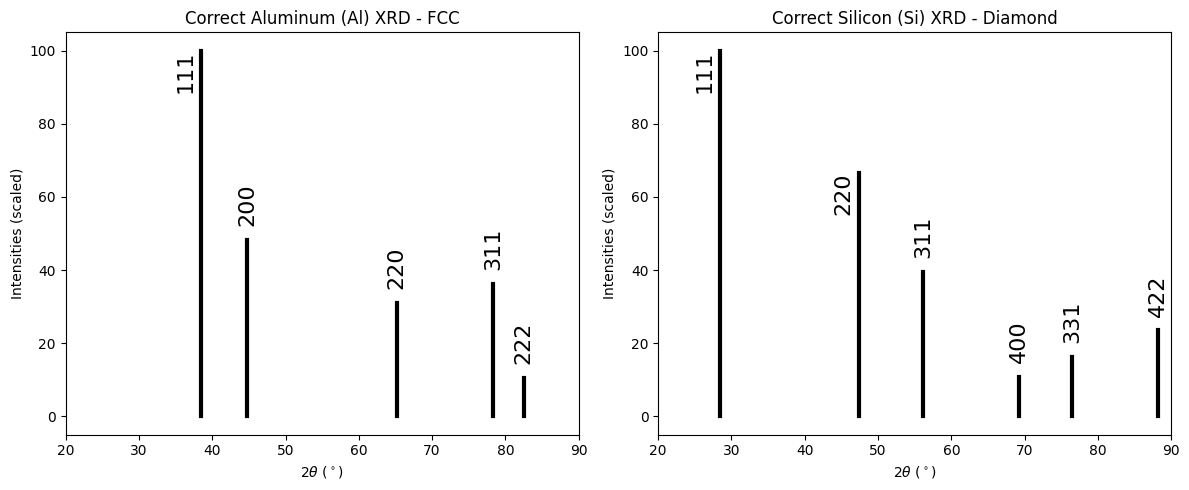

In [18]:
xrd_calc = XRDCalculator(wavelength="CuKa")

# 1. Correct Aluminum: FCC (Space group 225: Fm-3m)
al_structure = Structure.from_spacegroup(
    "Fm-3m", 
    Lattice.cubic(4.05), 
    ["Al"], 
    [[0, 0, 0]]
)

# 2. Correct Silicon: Diamond Cubic (Space group 227: Fd-3m)
si_structure = Structure.from_spacegroup(
    "Fd-3m", 
    Lattice.cubic(5.43), 
    ["Si"], 
    [[0, 0, 0]]
)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

xrd_calc.get_plot(al_structure, ax=ax1)
ax1.set_title("Correct Aluminum (Al) XRD - FCC")
ax1.set_xlim(20, 90)

xrd_calc.get_plot(si_structure, ax=ax2)
ax2.set_title("Correct Silicon (Si) XRD - Diamond")
ax2.set_xlim(20, 90)

plt.tight_layout()
plt.show()

In [23]:
print(datasets[0]['xrd_data']['intensity'])

KeyError: 'intensity'

In [22]:
for data in datasets:
    print(data['xrd_data']['name'])
    print(data['xrd_data']['intensity_003'])

Control
2976.0
NaVO$_3$ after immersion
2354.0
NaVO$_3$ before immersion
2407.0
MBT after immersion
2528.0
MBT before immersion
2105.0


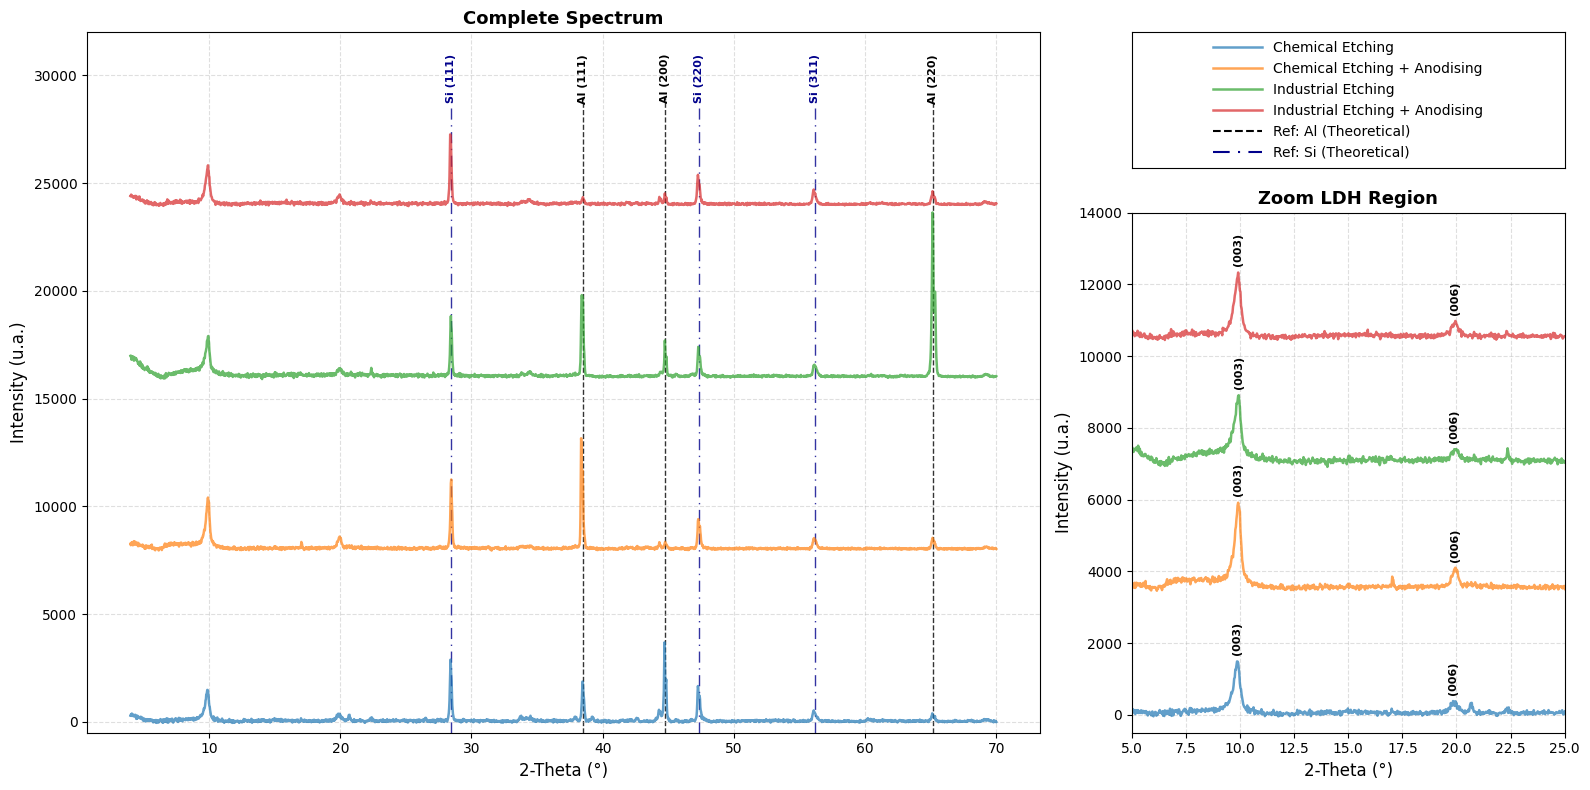

In [87]:
fig = plt.figure(figsize=(16, 8))

# 2. Definir a grelha (2 linhas e 2 colunas)
gs = gridspec.GridSpec(2, 2, width_ratios=[2.2, 1], height_ratios=[1.7, 6.5])

# 3. Alocar os eixos com base no teu esquema
ax_overall = fig.add_subplot(gs[:, 0])  
ax_leg     = fig.add_subplot(gs[0, 1])  
ax_zoom    = fig.add_subplot(gs[1, 1])  

# Definição dos teus offsets anteriores
offset_completo = 8000
offset_zoom = 3500

allowed_zoom_indices = [0, 1, 2, 3]
offset_006 = [0,-720,-400,-250,]
zoom_idx = 0

# Loop para plotar os dados nos respetivos eixos
for i, data in enumerate(datasets):
    x = data['xrd_data']['two_theta']
    y = data['xrd_data']['intensity_filtered']
    name = data['xrd_data']['name']
    two_theta_003 = data['xrd_data']['two_theta_003']
    intensity_003 = data['xrd_data']['intensity_003']
    two_theta_006 = data['xrd_data']['two_theta_006']
    intensity_006 = data['xrd_data']['intensity_003']
    
    # Plot no painel "OVERALL"
    ax_overall.plot(
        x, 
        y + (offset_completo * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=name
    )

    if i in allowed_zoom_indices:
        ax_zoom.plot(x, y + (offset_zoom * zoom_idx), alpha=0.7, linewidth=1.8)
        ax_zoom.text(two_theta_003, intensity_003 + 1100 + (offset_zoom * zoom_idx), "(003)", 
                     color='black', fontsize=8, rotation=90, ha='center', va='top', fontweight='bold')
        ax_zoom.text(two_theta_006, intensity_006 + offset_006[i] + (offset_zoom * zoom_idx), "(006)", 
                     color='black', fontsize=8, rotation=90, ha='center', va='top', fontweight='bold')
        
        zoom_idx += 1

xrd_calc = XRDCalculator(wavelength="CuKa")

# 1. Gerar as estruturas corretas
al_struct = Structure.from_spacegroup("Fm-3m", Lattice.cubic(4.05), ["Al"], [[0, 0, 0]])
si_struct = Structure.from_spacegroup("Fd-3m", Lattice.cubic(5.43), ["Si"], [[0, 0, 0]]) 

al_pattern = xrd_calc.get_pattern(al_struct)
si_pattern = xrd_calc.get_pattern(si_struct)

y_texto_fixo = 31000  

# 2. Desenhar picos e números do Alumínio (Preto)
for i in range(len(al_pattern.x)):
    x_val = al_pattern.x[i]
    y_val = al_pattern.y[i]
    
    # Só processa se o pico estiver no eixo X do gráfico e for um pico principal (>15% intensidade)
    if x_val <= 70 and y_val > 15: 
        # Extrai o tuplo HKL (ex: (1, 1, 1)) e converte para string limpa "(111)"
        hkl_tuple = al_pattern.hkls[i][0]['hkl']
        hkl_str = f"({hkl_tuple[0]}{hkl_tuple[1]}{hkl_tuple[2]})"
        
        # Linha vertical suave que atravessa todo o gráfico (-500 até 28000)
        ax_overall.vlines(x_val, -500, 29000, colors='black', 
                          linestyles='dashed', alpha=0.8, linewidth=1.0, zorder=1)
        
        # Texto elegante "pendurado" do topo (va='top')
        ax_overall.text(x_val, y_texto_fixo, f"Al {hkl_str}", color='black', 
                        fontsize=8, rotation=90, ha='center', va='top', fontweight='bold')

# 3. Desenhar picos e números do Silício (Cinzento)
for i in range(len(si_pattern.x)):
    x_val = si_pattern.x[i]
    y_val = si_pattern.y[i]
    
    if x_val <= 70 and y_val > 15:
        hkl_tuple = si_pattern.hkls[i][0]['hkl']
        hkl_str = f"({hkl_tuple[0]}{hkl_tuple[1]}{hkl_tuple[2]})"
        
        # Linha vertical pontilhada
        ax_overall.vlines(x_val, -500, 29000, colors='darkblue', 
                          linestyles=(0, (8, 4, 1, 4)), alpha=0.8, linewidth=1.0, zorder=1)
        
        # Texto elegante "pendurado" do topo (va='top') com um ligeiro desvio vertical se coincidir
        ax_overall.text(x_val, y_texto_fixo, f"Si {hkl_str}", color='darkblue', 
                        fontsize=8, rotation=90, ha='center', va='top',fontweight='bold')

# Linhas fantasma para a legenda
ax_overall.plot([], [], color='black', linestyle='--', label='Ref: Al (Theoretical)')
ax_overall.plot([], [], color='darkblue', linestyle=(0, (8, 4, 1, 4)), label='Ref: Si (Theoretical)')

# 4. Formatações finais dos eixos
ax_overall.set_ylim(-500, 32000)
ax_overall.set_xlabel('2-Theta (°)', fontsize=12)
ax_overall.set_ylabel('Intensity (u.a.)', fontsize=12)
ax_overall.set_title('Complete Spectrum', fontsize=13, fontweight='bold')
ax_overall.grid(True, linestyle='--', alpha=0.4)

ax_leg.get_xaxis().set_visible(False)
ax_leg.get_yaxis().set_visible(False)

# Isto vai recolher os teus espectros + as duas referências teóricas automaticamente
handles, labels = ax_overall.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', frameon=False, fontsize=10, handlelength=3.5)

ax_zoom.set_xlim(5, 25)
ax_zoom.set_ylim(-500, 14000)
ax_zoom.set_xlabel('2-Theta (°)', fontsize=12)
ax_zoom.set_ylabel('Intensity (u.a.)', fontsize=12)
ax_zoom.set_title('Zoom LDH Region', fontsize=13, fontweight='bold')
ax_zoom.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('XRD_LDH.pdf', bbox_inches='tight')
plt.show()